# What downscaling algorithm to use in human gaze data?

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

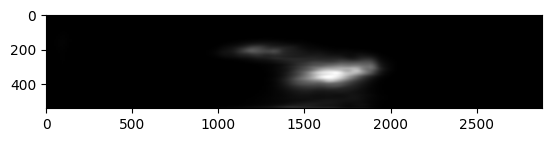

In [2]:
gaze = '/data-net/ted/extra_data_diego/ted_carla0914_additionalweathers/ClearNight/ClearNight_route00000/scout14ep1_000350.png'
img = Image.open(gaze)
img = np.array(img)

plt.imshow(img)
plt.show()

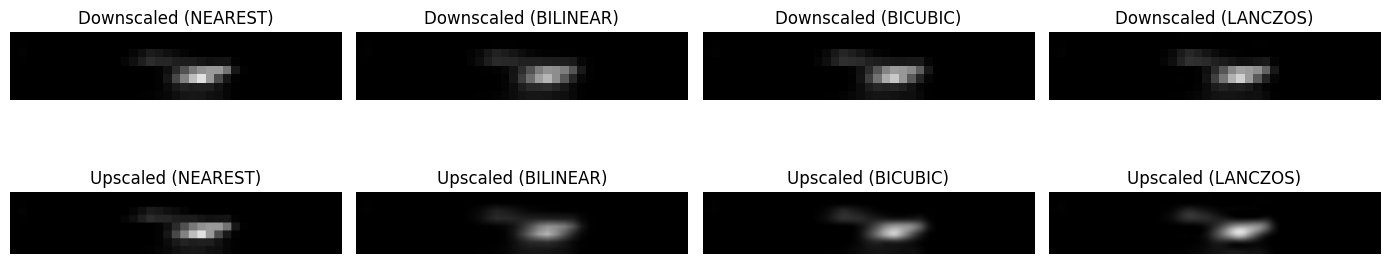

In [3]:
# Now, downscale it with different algorithms to size H=10 and W=30
# and compare them when upscaling back to the original size

original_size = (img.shape[1], img.shape[0])
downscale_size = (39, 8)

algorithms = {
    'NEAREST': Image.NEAREST,
    'BILINEAR': Image.BILINEAR,
    'BICUBIC': Image.BICUBIC,
    'LANCZOS': Image.LANCZOS
}

fig, axs = plt.subplots(2, len(algorithms), figsize=(14, 4))
for i, (name, algo) in enumerate(algorithms.items()):
    # Downscale
    img_pil = Image.fromarray(img)
    downscaled = img_pil.resize(downscale_size, algo)
    
    # Upscale back to original size
    upscaled = downscaled.resize(original_size, algo)
    
    # Display downscaled image
    axs[0, i].imshow(downscaled)
    axs[0, i].set_title(f'Downscaled ({name})')
    axs[0, i].axis('off')
    
    # Display upscaled image
    axs[1, i].imshow(upscaled)
    axs[1, i].set_title(f'Upscaled ({name})')
    axs[1, i].axis('off')
plt.tight_layout()
plt.show()

In [5]:
from typing import List
import re

def extract_camera_suffixes(camera_names: List[str]) -> List[str]:
    """
    Extract the suffixes from the camera names, which are used to identify the attention map classes.
    The suffixes are either "dynamic", "traffic", "human", "static", or "" (empty string).
    """
    suffixes = set()
    for name in camera_names:
        # Filter out cameras with 'rgb' in their names
        if 'rgb' in name.lower():
            continue
        # Remove the new prefix (e.g., 'avg_2sec_') and the common 'virtual_attention_' prefix
        name = re.sub(r'^avg_\d+sec_', '', name)
        name = name.replace('virtual_attention_', '')
        # Remove the 'noise_X_' part
        name = re.sub(r'noise_\d+_', '', name)
        # Split and remove camera direction words
        parts = name.split('_')
        suffix = '_'.join(part for part in parts if part not in ['central', 'left', 'right'])
        if suffix:
            suffixes.add(suffix)
    return [''] if not suffixes else list(suffixes)


In [7]:
extract_camera_suffixes(['ar_resized_rgb_left', 'ar_resized_rgb_central', 'gaze_pred', 'scout14ep1'])

['gaze_pred', 'scout14ep1']